This notebook explores Salinity, Latitude and Sea surface temperature influence on MP concentration in sediments

In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

## Salinity

Salinity data comes from Coperincus Marine service (https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_PHY_001_024/services). Monthly values between 01/03/2022 and 01/03/2024 were averaged to obtain an annual mean. The choice of date was motivated by the imposibility to download larger files. Only surface values are considered.

In [2]:
ds = nc.Dataset('inputs\cmems_mod_glo_phy-so_anfc_0.083deg_P1M-m_1777965288314.nc')

In [3]:
ds.variables.keys()

dict_keys(['time', 'depth', 'latitude', 'longitude', 'so'])

In [4]:
lat_grid = ds.variables['latitude'][:]
lon_grid = ds.variables['longitude'][:]

In [5]:
salinity = ds.variables["so"][:]  # shape: (time, depth, lat, lon)
salinity_mean = np.mean(salinity, axis=0)  # mean over time
salinity_mean = salinity_mean[0, :, :]     # surface only

In [7]:
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points.head()

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1


In [8]:
lat = data_points['Lat_center'].to_list()
lon = data_points['Lon_center'].to_list()

In [9]:
def get_salinity(lat_query, lon_query,output_storage, search_radius=10, ):
    """
    Get salinity at (lat_query, lon_query).
    If the nearest cell is NaN (land/gap), searches within
    a growing window for the nearest valid offshore cell.
    """
    lat_idx = np.argmin(np.abs(lat_grid - lat_query))
    lon_idx = np.argmin(np.abs(lon_grid - lon_query))

    sal = salinity_mean[lat_idx, lon_idx]

    found_idx = (lat_idx, lon_idx)
    fallback = False

    if np.isnan(sal):
        fallback = True
        # Search expanding neighborhood for nearest valid cell
        found = False
        for r in range(1, search_radius + 1):
            la_slice = slice(max(0, lat_idx - r), min(salinity_mean.shape[0], lat_idx + r + 1))
            lo_slice = slice(max(0, lon_idx - r), min(salinity_mean.shape[1], lon_idx + r + 1))
            patch = salinity_mean[la_slice, lo_slice]
            valid = np.argwhere(~np.isnan(patch))
            if len(valid) > 0:
                # Pick the one closest to center
                center = np.array([r, r])
                dists = np.linalg.norm(valid - center, axis=1)
                best = valid[np.argmin(dists)]
                found_idx = (la_slice.start + best[0], lo_slice.start + best[1])
                sal = salinity_mean[found_idx]
                found = True
                break
        if not found:
            print(f"No valid data within search radius for ({lat_query}, {lon_query})")
            return None, None

    output_storage.append((sal))

    return sal

In [10]:
out=[]
for i in range(len(lat)):
    get_salinity(lat[i], lon[i], output_storage=out)

In [11]:
output = pd.DataFrame(out, columns=['Salinity (psu)'])
output['Salinity (psu)'] = np.array(output['Salinity (psu)'], dtype=float)

c:\Users\nelad\miniforge3\envs\Rapport_env\Lib\site-packages\pandas\core\internals\construction.py:535: UserWarning: Warning: converting a masked element to nan.
  values = np.array([convert(v) for v in values])


In [12]:
data_points_expended = pd.concat([data_points, output], axis = 1)
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Salinity (psu)
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,NaN
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,NaN
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,NaN
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,35.659973
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,NaN
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,29.825234
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,29.783370
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,29.507427
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,29.536926


In [13]:
data_points_expended.to_csv('outputs\Salinity dataset.csv', index=False)

### Plot

In [14]:
latitudes_data  = np.array(data_points["Lat_center"], dtype=float)
longitudes_data = np.array(data_points["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

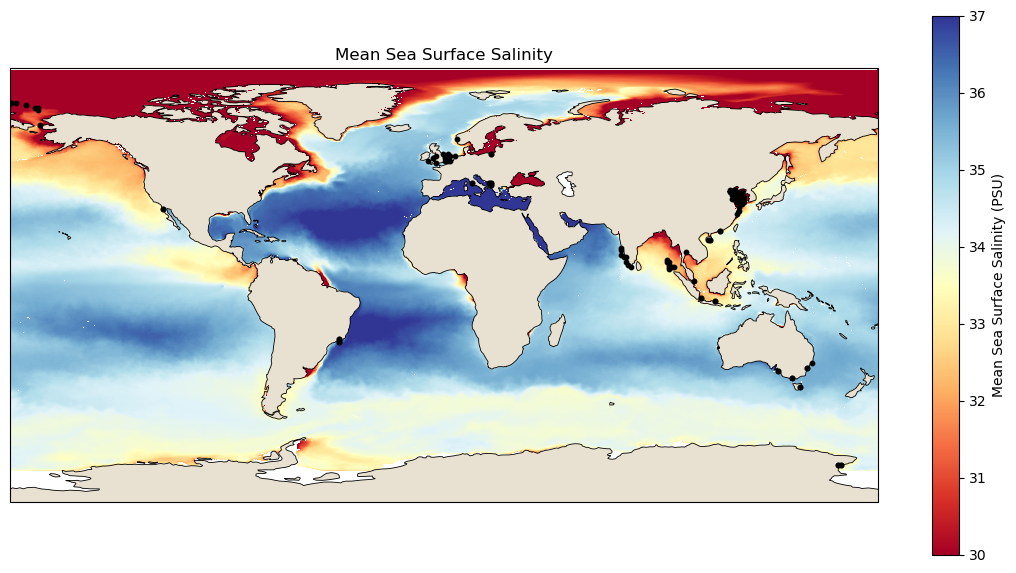

In [15]:
lats = ds.variables["latitude"][:]
lons = ds.variables["longitude"][:]

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

im = ax.pcolormesh(lons, lats, salinity_mean, cmap="RdYlBu", transform=ccrs.PlateCarree(), vmin=30, vmax=37)
ax.scatter(lons_data, lats_data, color="black", s=10, transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax, label="Mean Sea Surface Salinity (PSU)")

plt.title("Mean Sea Surface Salinity")
plt.show()

### Statistics

In [15]:
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Salinity (psu)
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,NaN
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,NaN
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,NaN
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,35.659973
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,NaN
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,29.825234
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,29.783370
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,29.507427
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,29.536926


In [16]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     'Salinity (psu)']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])
# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


In [17]:
cmap = plt.colormaps['plasma']
data_points_copy["Author"] = data_points_copy.index
colors = cmap(np.linspace(0, 1, len(data_points_copy["Author"].unique())))

C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\602477447.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 0].scatter(subset['Salinity (psu)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\602477447.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 1].scatter(subset['Salinity (psu)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])


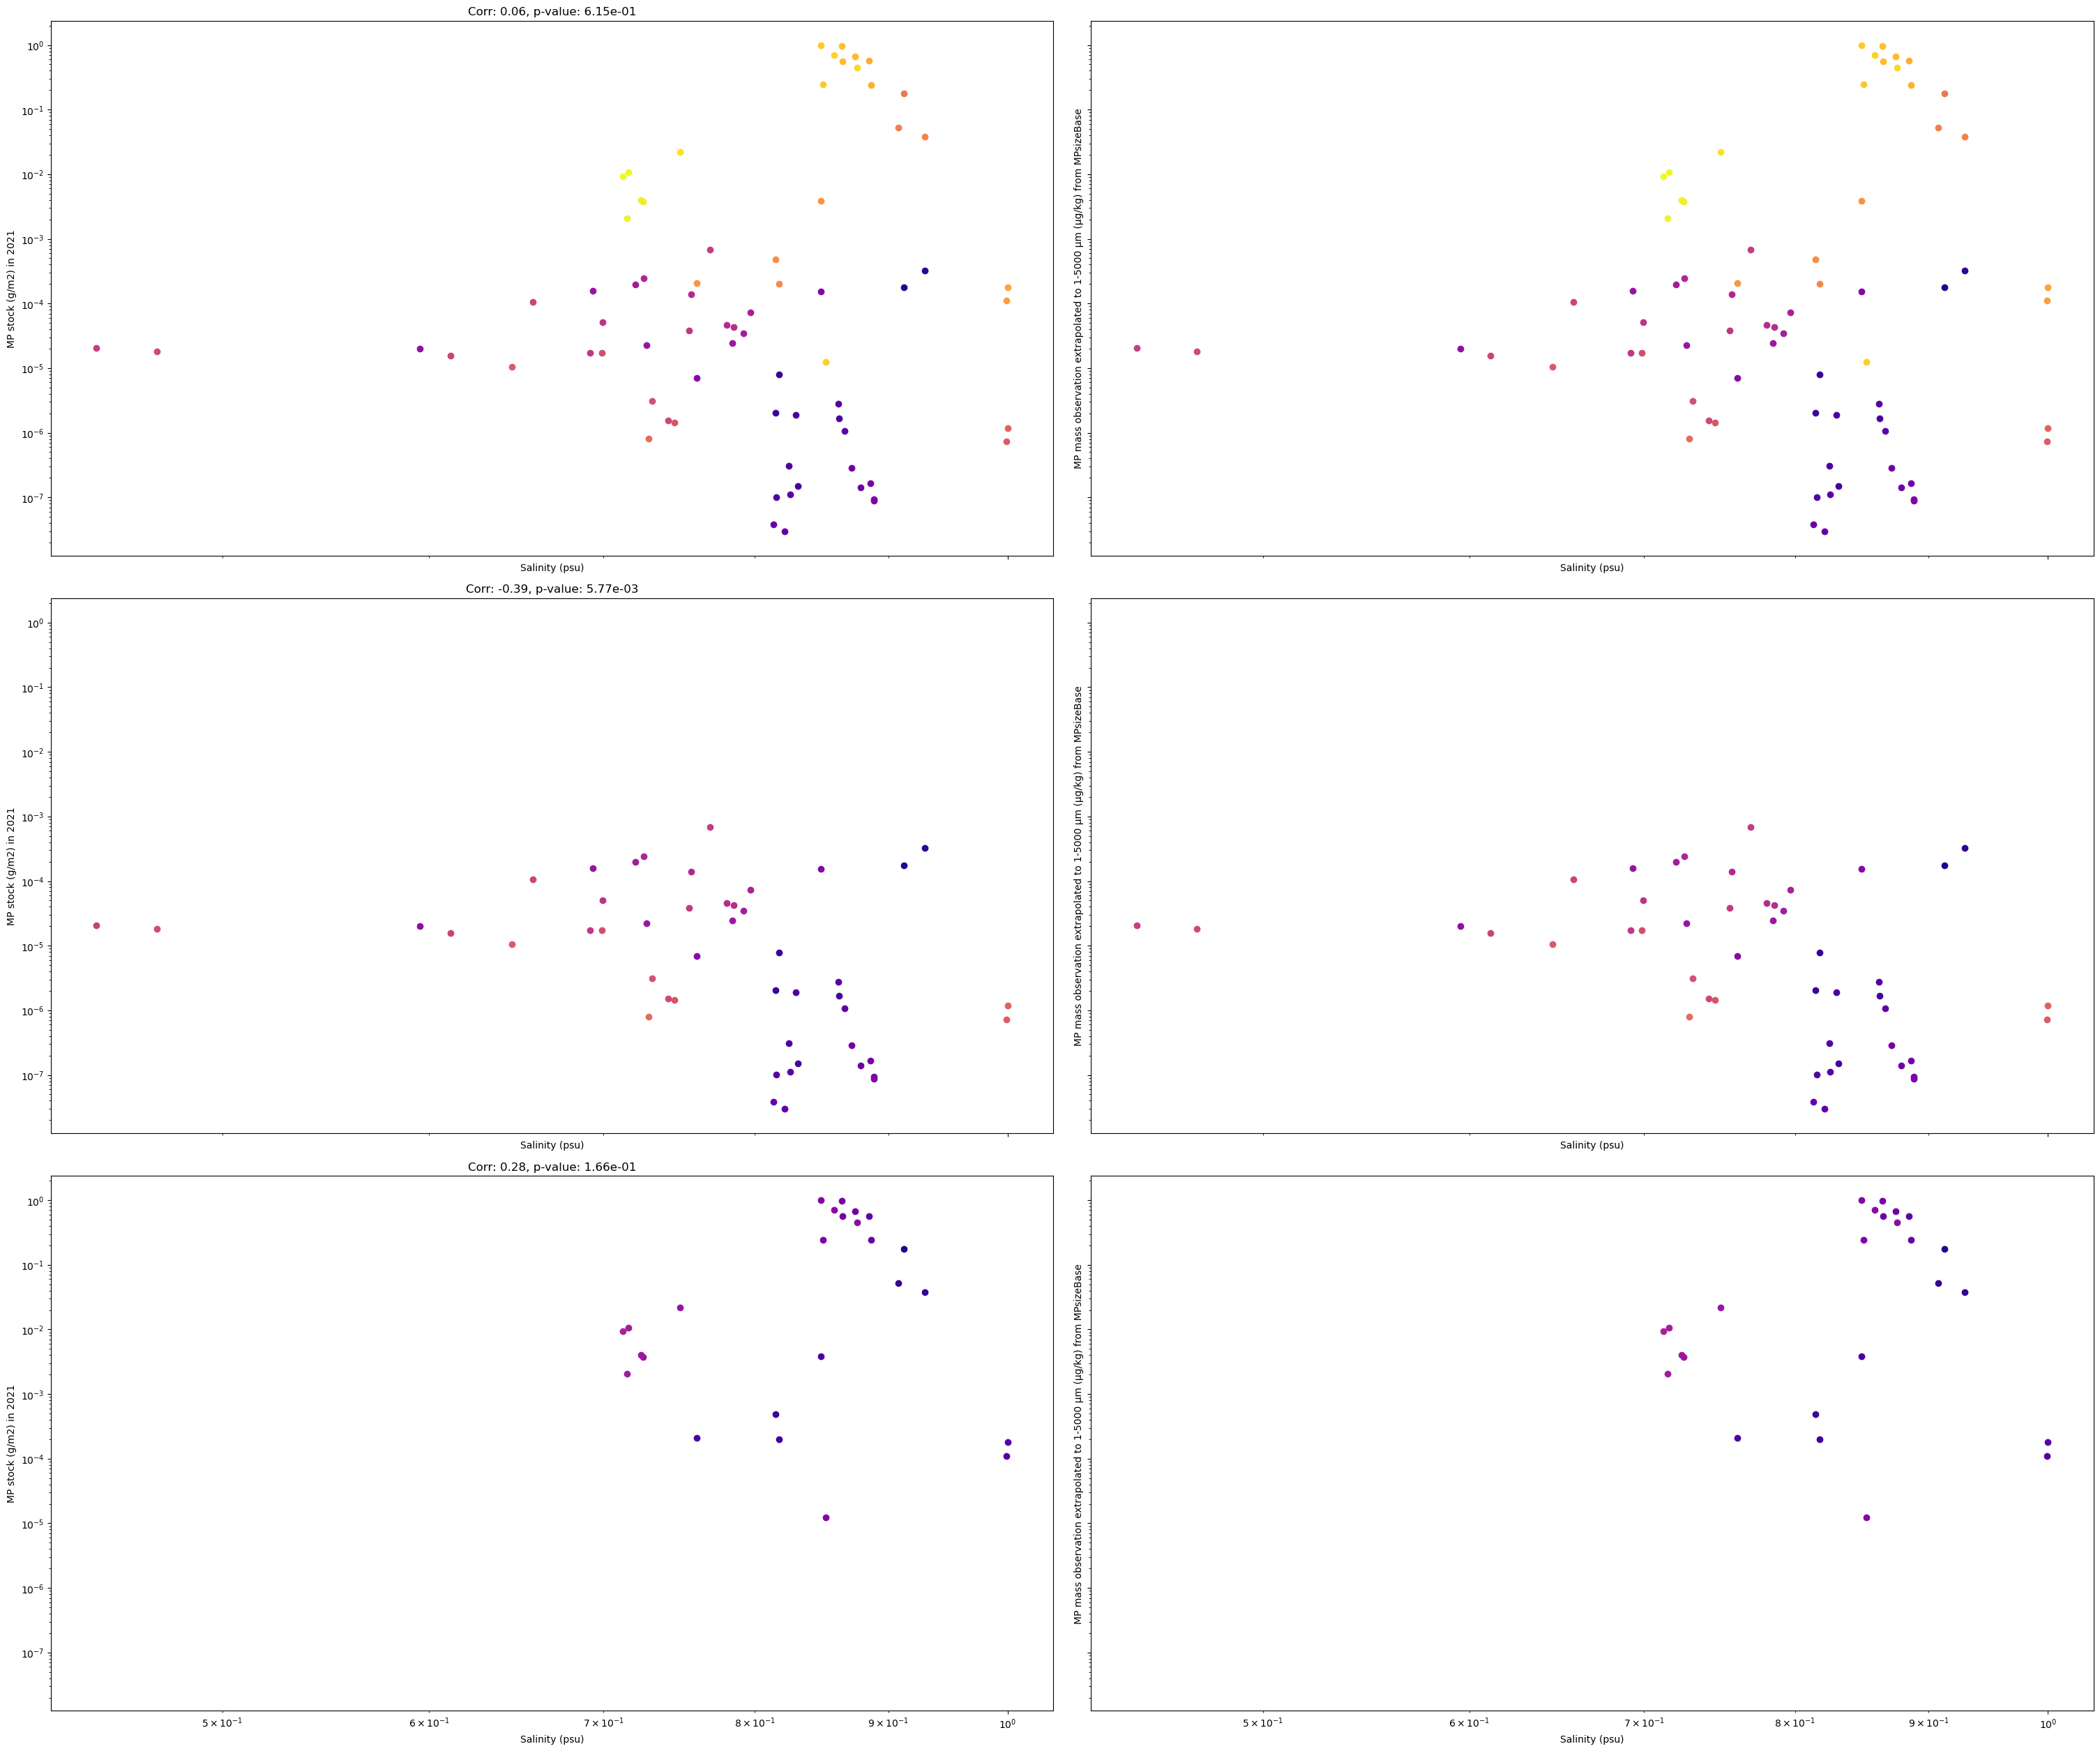

In [18]:
variables = ['MP stock (g/m2) in 2021']
datasets = [data_points_copy,data_points_fib,data_points_frg]
sh = ['Both', 'Fibers', 'Fragments']

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []
n = 0
for dataset in datasets:
    dataset['Author'] = dataset.index
    x = dataset['Salinity (psu)']    
    y = dataset['MEAN MP stock (g/m2) in 2021']


    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'Salinity stock {sh[n]}', spearman_stock[0], spearman_stock[1]))

    for i, author in enumerate(dataset["Author"].unique()):
            
        subset = dataset[dataset["Author"] == author]

        axs[n, 0].scatter(subset['Salinity (psu)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 0].set_xlabel('Salinity (psu)')
        axs[n, 0].set_ylabel('MP stock (g/m2) in 2021')
        axs[n, 0].set_title(f"Corr: {spearman_stock[0]:.2f}, p-value: {spearman_stock[1]:.2e}")
            
        axs[n, 1].scatter(subset['Salinity (psu)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 1].set_xlabel('Salinity (psu)')
        axs[n, 1].set_ylabel('MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase')

    

    plt.xscale("log")
    plt.yscale("log")

    n = n+1


In [19]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
1,Salinity stock Fibers,-0.388776,0.005768
0,Salinity stock Both,0.059079,0.614622
2,Salinity stock Fragments,0.280000,0.165929


## Latitude

In [20]:
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [21]:
# Normalize data for statistics
data_points_copy = data_points.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     'Lat_center']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])
# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\2130668361.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 0].scatter(subset['Lat_center'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\2130668361.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 1].scatter(subset['Lat_center'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])


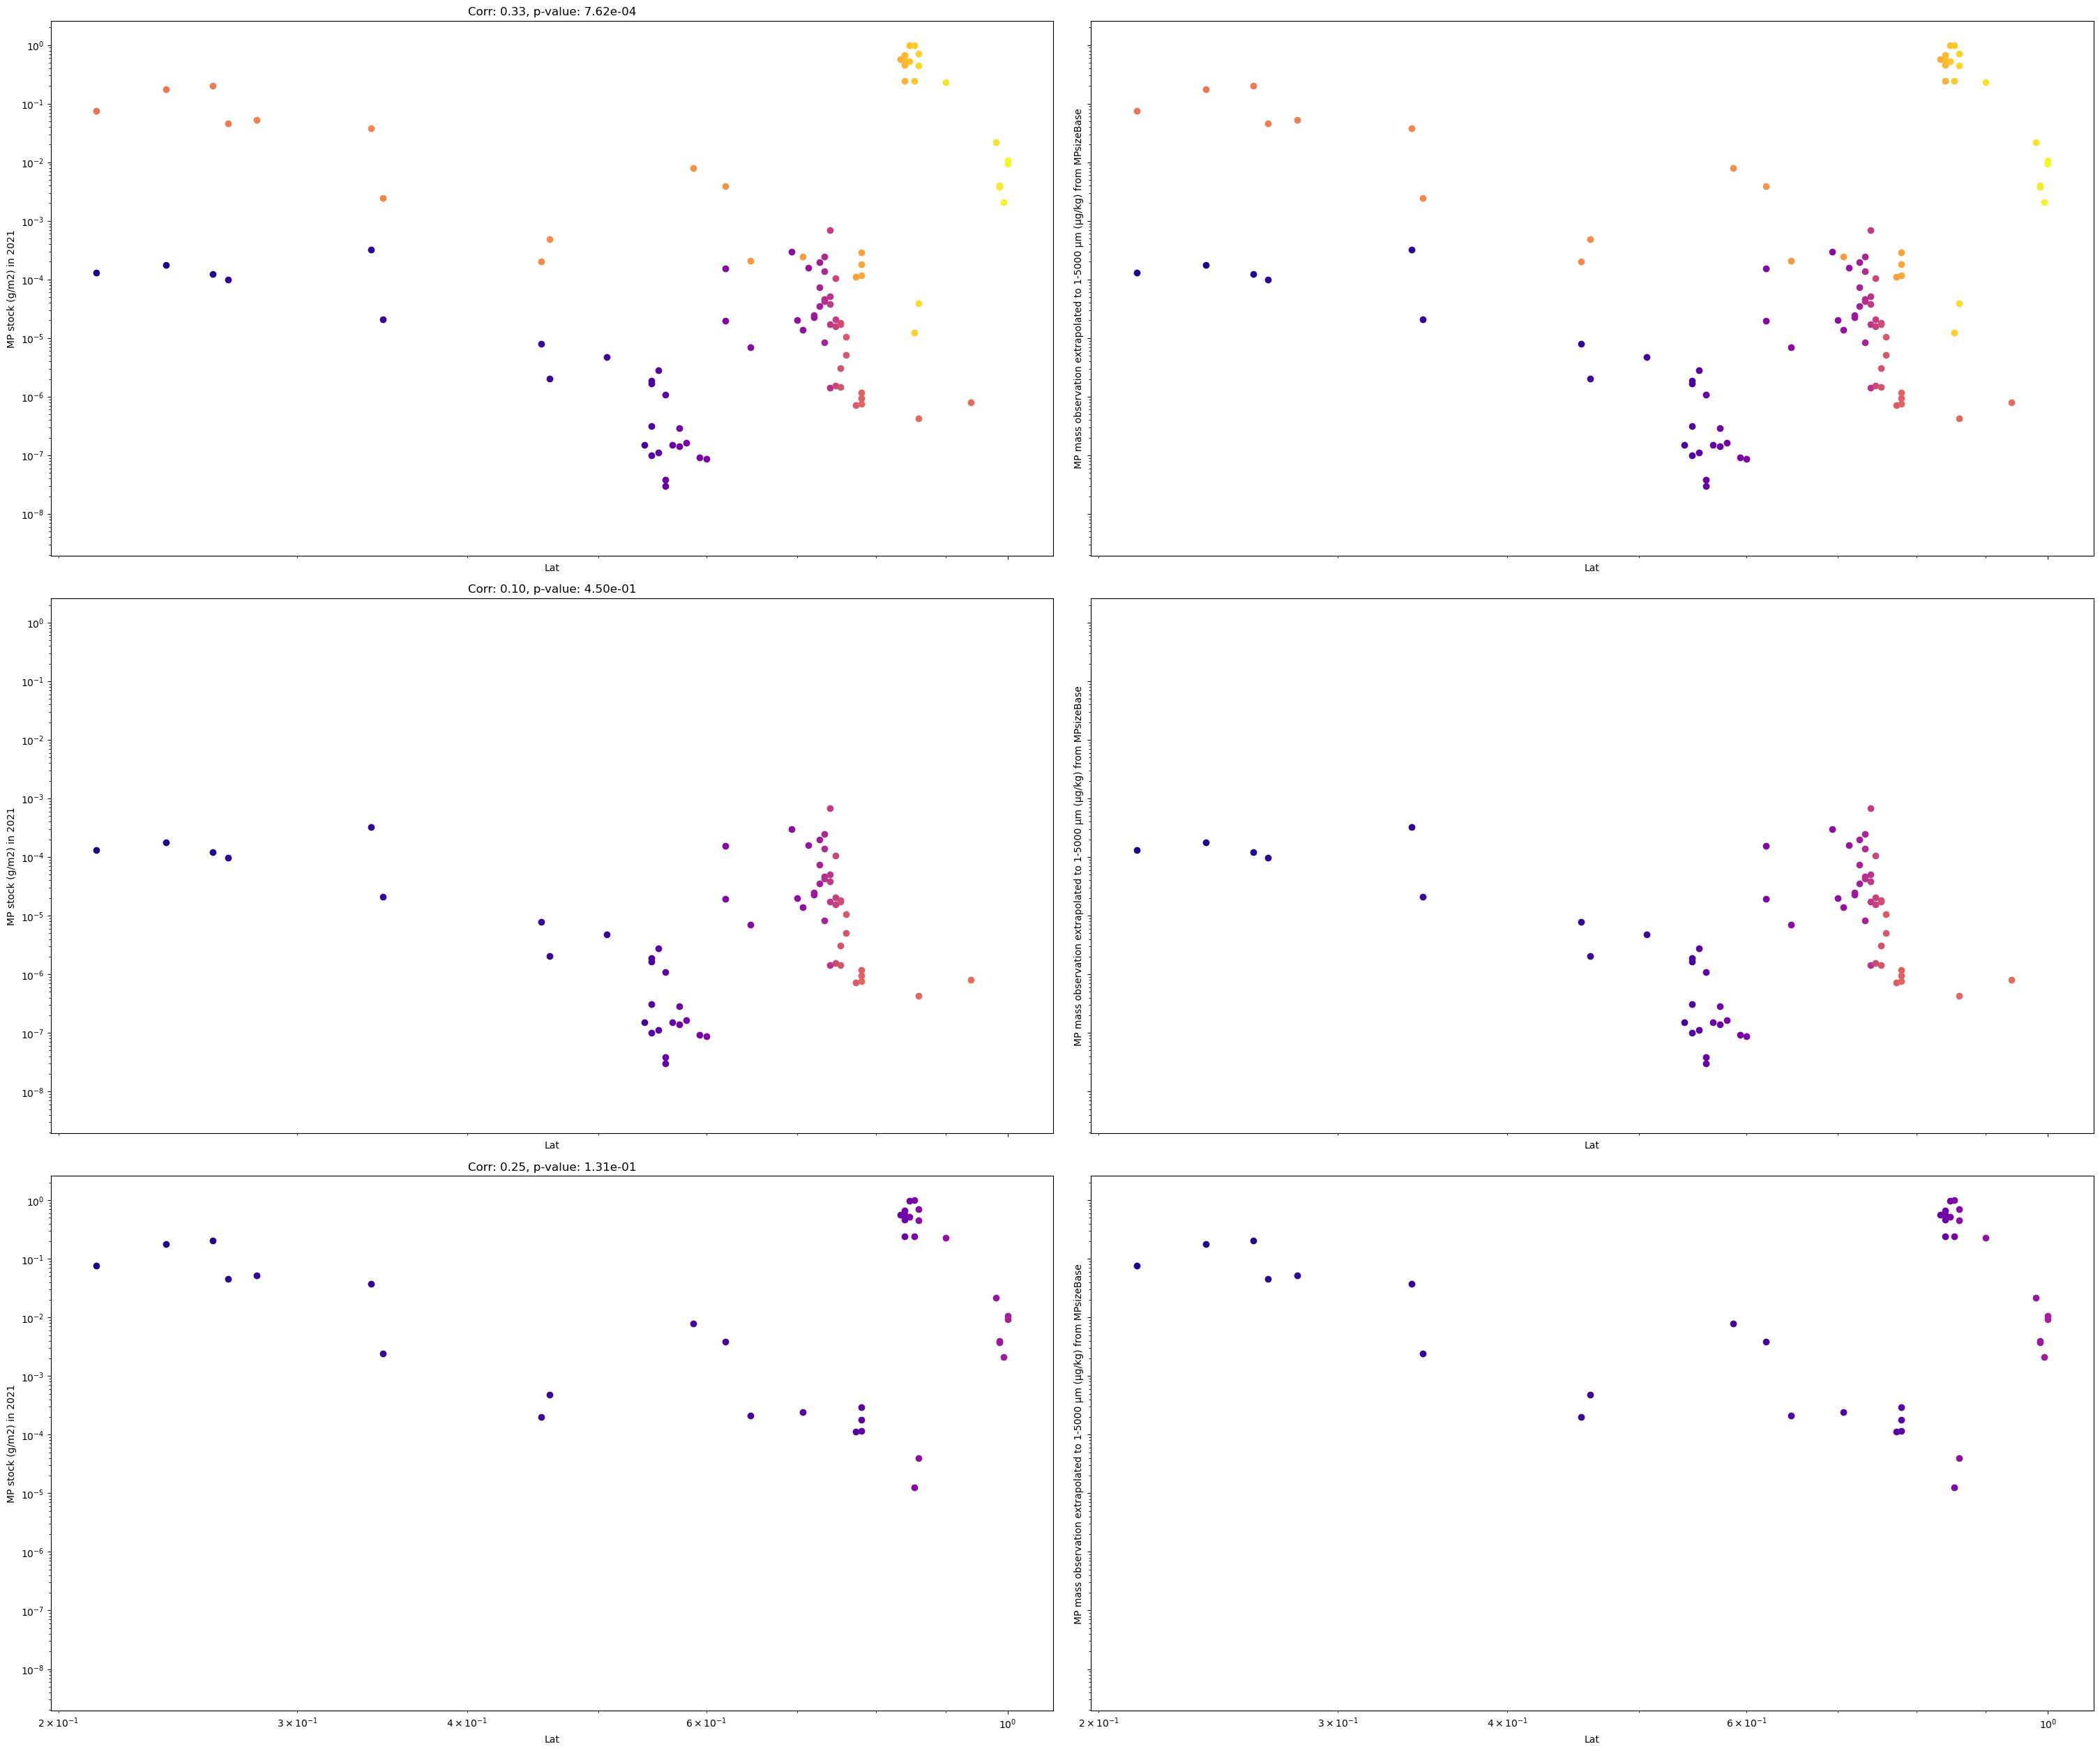

In [22]:
variables = ['MEAN MP stock (g/m2) in 2021']
datasets = [data_points_copy,data_points_fib,data_points_frg]
sh = ['Both', 'Fibers', 'Fragments']

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []
n = 0
for dataset in datasets:
    dataset['Author'] = dataset.index
    x = dataset['Lat_center']    
    y = dataset['MEAN MP stock (g/m2) in 2021']


    mask = np.isfinite(x) & np.isfinite(y) 
    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'Lat stock {sh[n]}', spearman_stock[0], spearman_stock[1]))

    for i, author in enumerate(dataset["Author"].unique()):
            
        subset = dataset[dataset["Author"] == author]

        axs[n, 0].scatter(subset['Lat_center'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 0].set_xlabel('Lat')
        axs[n, 0].set_ylabel('MP stock (g/m2) in 2021')
        axs[n, 0].set_title(f"Corr: {spearman_stock[0]:.2f}, p-value: {spearman_stock[1]:.2e}")
            
        axs[n, 1].scatter(subset['Lat_center'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 1].set_xlabel('Lat')
        axs[n, 1].set_ylabel('MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase')


    plt.xscale("log")
    plt.yscale("log")

    n = n+1


In [23]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
1,Lat stock Fibers,0.095328,0.450029
2,Lat stock Fragments,0.245870,0.131357
0,Lat stock Both,0.325016,0.000762


## Sea water potential temperature

Salinity data comes from Coperincus Marine service (https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_PHY_001_024/download?dataset=cmems_mod_glo_phy-thetao_anfc_0.083deg_P1M-m_202406). Monthly values between 01/03/2022 and 01/03/2024 were averaged to obtain an annual mean. The choice of date was motivated by the imposibility to download larger files. Only surface values (0.49 m deep) are considered.

In [24]:
ds = nc.Dataset('inputs\cmems_mod_glo_phy-thetao_anfc_0.083deg_P1M-m_1777965719424.nc')

parameters = ds.variables.keys()

""" Description of each variable
for param in parameters:
    var = ds.variables[param]
    print(f"\n{param}:")
    print(f"  long_name: {getattr(var, 'long_name', 'N/A')}")
    print(f"  units: {getattr(var, 'units', 'N/A')}")
    print(f"  standard_name: {getattr(var, 'standard_name', 'N/A')}")"""

' Description of each variable\nfor param in parameters:\n    var = ds.variables[param]\n    print(f"\n{param}:")\n    print(f"  long_name: {getattr(var, \'long_name\', \'N/A\')}")\n    print(f"  units: {getattr(var, \'units\', \'N/A\')}")\n    print(f"  standard_name: {getattr(var, \'standard_name\', \'N/A\')}")'

In [25]:
lat_grid = ds.variables['latitude'][:]
lon_grid = ds.variables['longitude'][:]

In [26]:
temperature = ds.variables["thetao"][:]  # shape: (time, depth, lat, lon)

temp_mean = np.mean(temperature, axis=0)  # mean over time -> shape: (depth, lat, lon)
temp_mean = temp_mean[0, :, :]     # surface only -> shape: (lat, lon)

In [27]:
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [28]:
lat = data_points['Lat_center'].to_list()
lon = data_points['Lon_center'].to_list()

In [29]:
def get_temperature(lat_query, lon_query,output_storage, search_radius=10, ):
    """
    Get temperature at (lat_query, lon_query).
    If the nearest cell is NaN (land/gap), searches within
    a growing window for the nearest valid offshore cell.
    """
    lat_idx = np.argmin(np.abs(lat_grid - lat_query))
    lon_idx = np.argmin(np.abs(lon_grid - lon_query))

    temp = temp_mean[lat_idx, lon_idx]

    found_idx = (lat_idx, lon_idx)
    fallback = False

    if np.isnan(temp):
        fallback = True
        # Search expanding neighborhood for nearest valid cell
        found = False
        for r in range(1, search_radius + 1):
            la_slice = slice(max(0, lat_idx - r), min(temp_mean.shape[0], lat_idx + r + 1))
            lo_slice = slice(max(0, lon_idx - r), min(temp_mean.shape[1], lon_idx + r + 1))
            patch = temp_mean[la_slice, lo_slice]
            valid = np.argwhere(~np.isnan(patch))
            if len(valid) > 0:
                # Pick the one closest to center
                center = np.array([r, r])
                dists = np.linalg.norm(valid - center, axis=1)
                best = valid[np.argmin(dists)]
                found_idx = (la_slice.start + best[0], lo_slice.start + best[1])
                temp = temp_mean[found_idx]
                found = True
                break
        if not found:
            print(f"No valid data within search radius for ({lat_query}, {lon_query})")
            return None, None

    output_storage.append((temp))

    return temp

In [30]:
out=[]
for i in range(len(lat)):
    get_temperature(lat[i], lon[i], output_storage=out)

In [31]:
output = pd.DataFrame(out, columns=['Temperature (°C)'])
output['Temperature (°C)'] = np.array(output['Temperature (°C)'], dtype=float)

c:\Users\nelad\miniforge3\envs\Rapport_env\Lib\site-packages\pandas\core\internals\construction.py:535: UserWarning: Warning: converting a masked element to nan.
  values = np.array([convert(v) for v in values])


In [32]:
data_points_expended = pd.concat([data_points, output], axis = 1)
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Temperature (°C)
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,NaN
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,NaN
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,NaN
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,15.698608
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,NaN
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,-1.118047
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,-1.109785
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,-1.297423
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,-1.496032


In [33]:
data_points_expended.to_csv('outputs\Sea surface temperature dataset.csv', index=False)

### Plot

In [34]:
latitudes_data  = np.array(data_points["Lat_center"], dtype=float)
longitudes_data = np.array(data_points["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

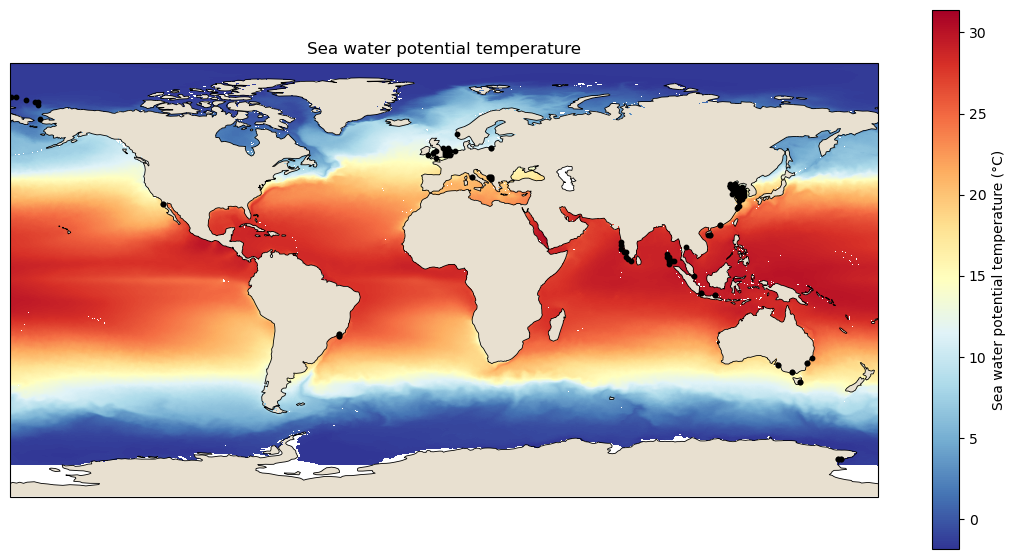

In [38]:
lats = ds.variables["latitude"][:]
lons = ds.variables["longitude"][:]

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

im = ax.pcolormesh(lons, lats, temp_mean, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
ax.scatter(lons_data, lats_data, color="black", s=10, transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax, label="Sea water potential temperature (°C)")

plt.title("Sea water potential temperature")
plt.show()

# Statistics

In [35]:
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Temperature (°C)
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,NaN
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,NaN
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,NaN
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,15.698608
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,NaN
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,-1.118047
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,-1.109785
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,-1.297423
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,-1.496032


In [36]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     'Temperature (°C)']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])
# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\2598168657.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 0].scatter(subset['Temperature (°C)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
C:\Users\nelad\AppData\Local\Temp\ipykernel_13636\2598168657.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 1].scatter(subset['Temperature (°C)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])


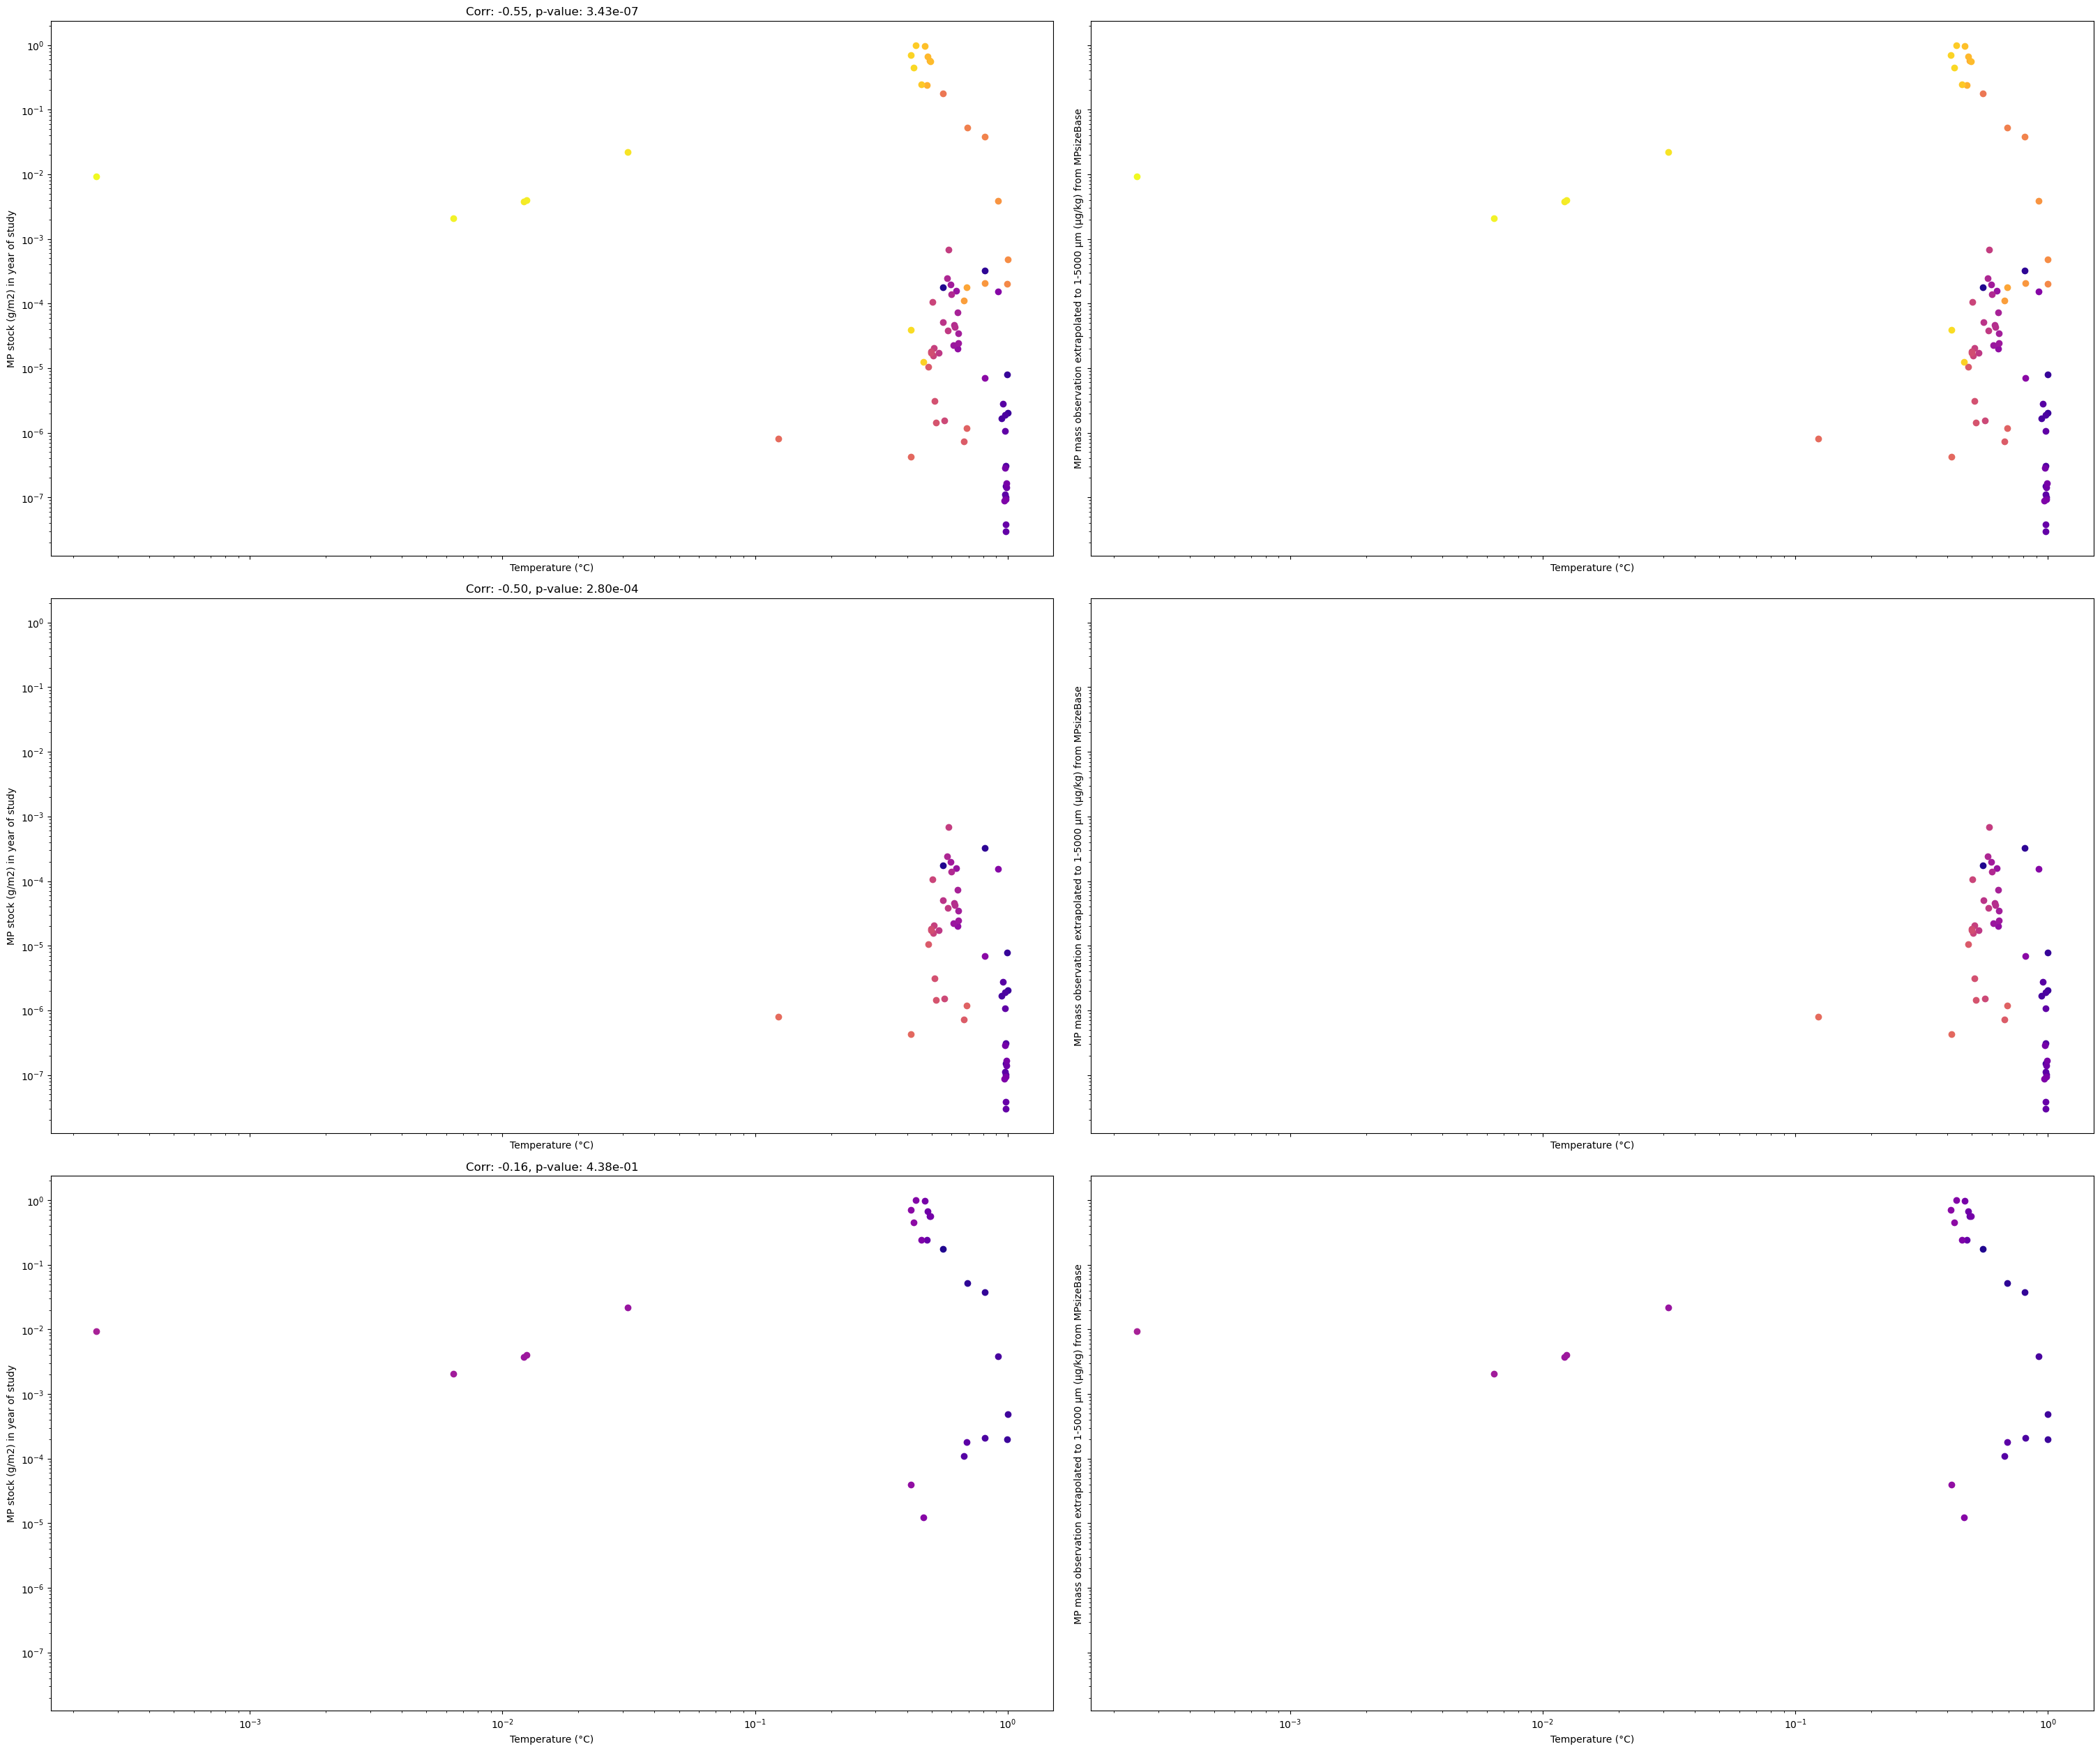

In [38]:
variables = ['MEAN MEAN MP stock (g/m2) in 2021']
datasets = [data_points_copy,data_points_fib,data_points_frg]
sh = ['Both', 'Fibers', 'Fragments']

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []
n = 0
for dataset in datasets:
    dataset['Author'] = dataset.index
    x = dataset['Temperature (°C)']    
    y = dataset['MEAN MP stock (g/m2) in 2021']


    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'Temperature stock {sh[n]}', spearman_stock[0], spearman_stock[1]))

    for i, author in enumerate(dataset["Author"].unique()):
            
        subset = dataset[dataset["Author"] == author]

        axs[n, 0].scatter(subset['Temperature (°C)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 0].set_xlabel('Temperature (°C)')
        axs[n, 0].set_ylabel('MP stock (g/m2) in year of study')
        axs[n, 0].set_title(f"Corr: {spearman_stock[0]:.2f}, p-value: {spearman_stock[1]:.2e}")
            
        axs[n, 1].scatter(subset['Temperature (°C)'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 1].set_xlabel('Temperature (°C)')
        axs[n, 1].set_ylabel('MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase')

    

    plt.xscale("log")
    plt.yscale("log")

    n = n+1


In [39]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
0,Temperature stock Both,-0.548812,3.434205e-07
1,Temperature stock Fibers,-0.497041,2.801341e-04
2,Temperature stock Fragments,-0.158974,4.379267e-01
